In [1]:
import torch
import torch.nn as nn
# from torchvision.transforms import v2 as transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.models.efficientnet import efficientnet_v2_s, EfficientNet_V2_S_Weights
import torch.nn.functional as F
from transformers import DistilBertTokenizer, DistilBertModel

from PIL import Image
import os

import matplotlib.pyplot as plt
import numpy as np

In [2]:
print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0))   

True
Tesla T4


In [3]:
from IPython.display import clear_output

In [4]:
# Initializations
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
import shutil

# Create a temp directory in the current working directory EARLY
# This ensures all subsequent code uses this isolated temp dir, avoiding system /tmp conflicts
notebook_tmp_dir = os.path.join(os.getcwd(), 'clip_temp')
if os.path.exists(notebook_tmp_dir):
    shutil.rmtree(notebook_tmp_dir)
os.makedirs(notebook_tmp_dir)

# Set environment so PyTorch uses this local directory instead of system /tmp
os.environ['TMPDIR'] = notebook_tmp_dir
os.environ['TMP'] = notebook_tmp_dir

print(f"✅ Temp directory setup at start: {notebook_tmp_dir}")

✅ Temp directory setup at start: /content/clip_temp


In [6]:
### Vision model
weights = EfficientNet_V2_S_Weights.DEFAULT # Load the pre-trained weights for the EfficientNet V2 S model
transforms = weights.transforms() # Define the transforms for the input images, which include resizing, normalization, and other necessary preprocessing steps
eff_net = efficientnet_v2_s(weights=weights) # Load the EfficientNet V2 S model with the pre-trained weights


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 167MB/s] 


In [7]:
### Text model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
text_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
# Vision Encider
class VisionEncoder(nn.Module):
    def __init__(self, hidden_dim, output_dim, freeze_backbone = True):
        super(VisionEncoder, self).__init__() 
        self.model = eff_net
        # freeze model weights
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        self.model.classifier = nn.Sequential(
         nn.Linear(in_features=1280, out_features=hidden_dim),
         nn.ReLU(),
         nn.Linear(in_features=hidden_dim, out_features=hidden_dim),
         nn.ReLU(), 
         nn.Linear(in_features=hidden_dim, out_features=output_dim) 
        )        

    def forward(self, x): # x is a batch of images, with shape (batch_size, 3, 224, 224) after applying the transforms
        return self.model(x)


In [9]:
### Text Encoder
class TextEncoder(nn.Module):
  def __init__(self, hidden_dim, output_dim, freeze_backbone=True):
    super(TextEncoder, self).__init__()
    self.model = text_model
    # freeze model weights
    if freeze_backbone:
      for param in self.model.parameters():
        param.requires_grad = False
        
    self.fc = nn.Sequential(
        nn.Linear(in_features=768, out_features=hidden_dim), #768 is the hidden size of distilbert
        nn.ReLU(),
        nn.Linear(in_features=hidden_dim, out_features=hidden_dim),
        nn.ReLU(),
        nn.Linear(in_features=hidden_dim, out_features=output_dim)
    )

  def forward(self, x):
    input_ids, attention_mask = x # x has size (batch_size, seq_len) for input_ids and attention_mask 
    output = self.model(input_ids=input_ids, attention_mask=attention_mask)
    last_hidden = output.last_hidden_state  # shape: (batch_size, seq_len, 768)
    # Use mask-aware mean pooling instead of CLS token for better sentence embeddings
    # Expand mask to match hidden state dimensions and apply it
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    sum_embeddings = (last_hidden * mask_expanded).sum(1)  # Sum only non-padded tokens
    sum_mask = mask_expanded.sum(1)
    x = sum_embeddings / (sum_mask + 1e-9)  # Mean pooling (account for variable seq lengths)
    return self.fc(x) # gives the final output of the text encoder after passing through the fully connected layers

In [10]:
class MiniCLIP(nn.Module):
  def __init__(self, vision_encoder, text_encoder):
    super(MiniCLIP, self).__init__()
    self.vision_encoder = vision_encoder
    self.text_encoder = text_encoder

    self.temperature = nn.Parameter(torch.tensor(1.0))

  def get_similarity(self, image_features, text_features):
    return (image_features @ text_features.T) * torch.exp(self.temperature)

  def get_image_features(self, image):
    return self.vision_encoder(image)

  def get_text_features(self, text):
    return self.text_encoder(text)

  def forward(self, image, text): # takes in a batch of images and a batch of text, and returns the similarity scores between them
    image_features = F.normalize(self.get_image_features(image))
    text_features = F.normalize(self.get_text_features(text))
    similarities = self.get_similarity(image_features, text_features) # shape is (batch_size, batch_size) and contains the similarity scores between each image and each text in the batch, used for the contrastive loss calculation
    # images may be same but captions will be different, so we want to maximize the similarity between the image and its corresponding caption, while minimizing the similarity between the image and other captions in the batch (and vice versa for the text)
    return similarities

In [11]:
class SymmetricLoss(nn.Module):
  def __init__(self):
    super(SymmetricLoss, self).__init__()

  def forward(self, logits, image_ids):
    """
    Multi-positive contrastive loss for multi-caption datasets (e.g., Flickr8k with 5 captions per image).
    
    Args:
        logits: (batch_size, batch_size) similarity matrix from image-text pairs in batch
        image_ids: (batch_size,) tensor indicating which unique image each caption belongs to
    
    For each image, all its captions in the batch are positive; others are negative.
    Uses soft labels with KL divergence for smooth gradient flow.
    """
    batch_size = logits.shape[0]
    device = logits.device
    
    # Create soft label matrix: mark all captions from same image as positive
    soft_labels = torch.zeros((batch_size, batch_size), device=device)
    for i in range(batch_size):
      for j in range(batch_size):
        if image_ids[i] == image_ids[j]:  # Same image = positive pair
          soft_labels[i, j] = 1.0
    
    # Normalize so each row sums to 1 (but exclude self if you want hard negative mining on self)
    # For now, we include self-pairs as they provide training signal
    soft_labels = soft_labels / soft_labels.sum(dim=1, keepdim=True)

    # Image-to-Text loss: for each image, minimize KL divergence from soft labels
    log_probs_i = F.log_softmax(logits, dim=1)  # (batch_size, batch_size)
    loss_i = -(soft_labels * log_probs_i).sum(dim=1).mean()
    
    # Text-to-Image loss: transpose for symmetric loss
    log_probs_t = F.log_softmax(logits.T, dim=1)  # (batch_size, batch_size)
    loss_t = -(soft_labels.T * log_probs_t).sum(dim=1).mean()
    
    # Symmetric loss
    sym_loss = (loss_i + loss_t) / 2
    return sym_loss

In [12]:
!wget -O data.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -O text.zip https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip data.zip -d data/
!unzip text.zip -d data/

# Clear output
clear_output()

In [13]:
import pandas as pd
import re
from pathlib import Path

# Load official Flickr8k splits (by image, not by caption rows)
data_root = Path('data')
token_file = data_root / 'Flickr8k.token.txt'

# Load all captions
captions_dict = {}  # {image_name: {cid: caption_text}}
pat = re.compile(r'^(?P<img>[^#]+)#(?P<cid>\d+)\t(?P<cap>.+)$')
for line in token_file.read_text(errors='ignore').splitlines():
    m = pat.match(line)
    if m:
        img = m.group('img')
        cid = int(m.group('cid'))
        cap = m.group('cap')
        if img not in captions_dict:
            captions_dict[img] = {}
        captions_dict[img][cid] = cap

# Load official split image lists
train_images = [l.strip() for l in (data_root / 'Flickr_8k.trainImages.txt').read_text(errors='ignore').splitlines() if l.strip()]
val_images = [l.strip() for l in (data_root / 'Flickr_8k.devImages.txt').read_text(errors='ignore').splitlines() if l.strip()]
test_images = [l.strip() for l in (data_root / 'Flickr_8k.testImages.txt').read_text(errors='ignore').splitlines() if l.strip()]

# Build DataFrames: each row is one (image, one_caption) pair
def build_df(image_list):
    rows = []
    for img_name in image_list:
        if img_name in captions_dict:
            # Each image has 5 captions; add all of them as separate rows for training variety
            for cid in range(5):
                if cid in captions_dict[img_name]:
                    rows.append([img_name, captions_dict[img_name][cid]])
    return pd.DataFrame(rows, columns=['image', 'caption'])

train_df = build_df(train_images)
val_df = build_df(val_images)
test_df = build_df(test_images)

print(f"Train: {len(train_images)} images, {len(train_df)} caption rows")
print(f"Val: {len(val_images)} images, {len(val_df)} caption rows")
print(f"Test: {len(test_images)} images, {len(test_df)} caption rows")
print(f"All captions loaded: {len(captions_dict)} unique images")

Train: 6000 images, 30000 caption rows
Val: 1000 images, 5000 caption rows
Test: 1000 images, 5000 caption rows
All captions loaded: 8092 unique images


In [14]:
# Pytorch dataset
class FlickrDataset(Dataset):
  def __init__(self, df, transform=transforms, image_folder=None):
    self.df = df
    self.transform = transform # transforms for the images
    self.folder = image_folder #  folder where images are stored
    # Create mapping from image name to unique ID for tracking which captions belong to which image
    self.unique_images = df['image'].unique()
    self.image_to_id = {img: idx for idx, img in enumerate(self.unique_images)}

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_name = self.df.iloc[idx, 0] 
    captions = self.df.iloc[idx, 1]  # One caption per row; there are 5 rows per image in the official splits
    tokens = self.transform_text(captions) # tokenize the captions using the DistilBert tokenizer

    input_ids = tokens.input_ids.squeeze() # shape is (1, max_length) so we squeeze to get (max_length,)
    attention_mask = tokens.attention_mask.squeeze() # to mask the padding tokens in the attention mechanism of the text encoder

    img_path = os.path.join(self.folder, img_name) 

    img = Image.open(img_path)
    img = self.transform(img) # apply the transformations to the image (resize, center crop, to tensor and normalize)
    
    # Return image_id so we can track which image this caption belongs to during training
    image_id = self.image_to_id[img_name]
    return img, (input_ids, attention_mask), image_id

  def transform_text(self, text):
    return tokenizer(text, return_tensors="pt", truncation=True, padding="max_length") 


IMAGE_DIR = 'data/Flicker8k_Dataset' 
train_dataset = FlickrDataset(train_df, transforms, IMAGE_DIR) 
val_dataset = FlickrDataset(val_df, transforms, IMAGE_DIR)
test_dataset = FlickrDataset(test_df, transforms, IMAGE_DIR)

In [15]:
# Clear GPU cache first
torch.cuda.empty_cache()
import gc
gc.collect()

267

In [16]:
# Create DataLoaders with parallelized data loading for speed
# (Temp dir already set up at notebook start)
BATCH_SIZE = 256  # Doubled from 128 - fewer iterations
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(f"✅ DataLoaders ready with BATCH_SIZE={BATCH_SIZE}, num_workers=2")
print(f"✅ Expected: ~120 batches/epoch with safe isolated temp dir")


✅ DataLoaders ready with BATCH_SIZE=256, num_workers=2
✅ Expected: ~120 batches/epoch with safe isolated temp dir


In [17]:
from torch.optim import AdamW
from torch.optim import lr_scheduler


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_HIDDEN_DIM = 512
IMAGE_OUTPUT_DIM = 256
TEXT_HIDDEN_DIM = 512
TEXT_OUTPUT_DIM = 256
EPOCHS = 10
LEARNNING_RATE = 1e-3

vision_encoder = VisionEncoder(IMAGE_HIDDEN_DIM, IMAGE_OUTPUT_DIM).to(DEVICE)
text_encoder = TextEncoder(TEXT_HIDDEN_DIM, TEXT_OUTPUT_DIM).to(DEVICE)
miniclip = MiniCLIP(vision_encoder, text_encoder).to(DEVICE)

optimizer = AdamW(miniclip.parameters(), lr=LEARNNING_RATE) 
scheduler = lr_scheduler.OneCycleLR(optimizer=optimizer, max_lr=LEARNNING_RATE, epochs=EPOCHS, steps_per_epoch=len(train_loader))
criterion = SymmetricLoss()

In [18]:
# ==========================================
# PARAMETER VERIFICATION & ALIGNMENT CHECK
# ==========================================
# VL-JEPA now aligns with CLIP's 256D embedding space
# Both vision and text features are normalized to 256D and L2-normalized

vision_trainable = sum(p.numel() for p in miniclip.vision_encoder.parameters() if p.requires_grad)
text_trainable = sum(p.numel() for p in miniclip.text_encoder.parameters() if p.requires_grad)


print("=" * 70)
print(f"Trainable parameters in Vision Backbone:   {vision_trainable:,}")
print(f"Trainable parameters in Text Backbone:     {text_trainable:,}")


Trainable parameters in Vision Backbone:   1,049,856
Trainable parameters in Text Backbone:     787,712


In [19]:
from tqdm import tqdm # for the progress bar in training loop
import gc
from torch.amp import autocast
from torch.cuda.amp import GradScaler

# Initialize the gradient scaler for mixed precision training
scaler = GradScaler()

def train_step(model, optimizer, criterion, dataloader):
  model.train() # set the model to training mode, this will enable dropout and layers like batchnorm to work in training mode
  total_loss = 0

  # Create the tqdm progress bar with a dynamic description, tqdm shows time
  progress_bar = tqdm(dataloader, # the dataloader for the training data
                      total=len(dataloader), # total number of batches in the dataloader
                      desc="Avg Train Loss: 0.000") # initial description of the progress bar, will be updated in each iteration with the average loss

  for i, batch in enumerate(progress_bar): # iterate through the dataloader
    try:
      # Unpack batch: now includes image_ids for multi-positive loss
      image, text, image_ids = batch
      image = image.to(DEVICE)
      input_ids, attention_mask = text[0].to(DEVICE), text[1].to(DEVICE)
      image_ids = image_ids.to(DEVICE) # shape is (batch_size,) and contains the unique image ID for each caption in the batch, used to determine positive pairs for the loss function

      # Optimizer zero grad
      optimizer.zero_grad()

      # 1. Run the forward pass with mixed precision
      with autocast(device_type='cuda', dtype=torch.float16):
          logits = model(image, (input_ids, attention_mask))# input is a batch of images and corresponding text (captions), output is the similarity scores between each image and each caption in the batch, shape is (batch_size, batch_size)
          loss = criterion(logits, image_ids)  # Pass image_ids for multi-positive loss

      # 2. Scale the loss and do backward pass
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()

      total_loss += loss.item()
      progress_bar.set_description(f"Avg Train Loss: {(total_loss / (i + 1)):.4f}")
    except Exception as e:
      print(e)
      continue
    
    torch.cuda.empty_cache()
    gc.collect()

  # Return the average loss for the epoch
  return total_loss / len(dataloader)

/tmp/ipykernel_1484/1255109563.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [20]:
def val_step(model, criterion, dataloader):
  model.eval() # set the model to evaluation mode, this will disable dropout and layers like batchnorm to work in evaluation mode
  with torch.inference_mode(): # to disable gradient calculation, we don't need it for validation and it will speed up the computations and reduce memory usage
    total_loss = 0

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Avg Val Loss: 0.000")

    for i, batch in enumerate(progress_bar):
      # Put everything on the same device
      try:
        # Unpack batch: now includes image_ids for multi-positive loss
        image, text, image_ids = batch
        image = image.to(DEVICE)
        input_ids, attention_mask = text[0].to(DEVICE), text[1].to(DEVICE)
        image_ids = image_ids.to(DEVICE)

        # Get logits
        logits = model(image, (input_ids, attention_mask))

        # Calculate loss with image_ids for multi-positive loss
        loss = criterion(logits, image_ids)
        total_loss += loss.item()

        # Update the tqdm description with the running average loss
        avg_loss = total_loss / (i + 1)
        progress_bar.set_description(f"Avg Val Loss: {avg_loss:.4f}")

      except Exception as e:
        print(e)

  # Return the average loss for the epoch
  return total_loss / len(dataloader)

# stop

In [21]:
def train(model, optimizer, criterion, train_loader, val_loader, epochs=10):
  # setting evaluations
  history = {
        "train_loss": [],
        "val_loss": [],
    }
  for epoch in range(epochs):
    
    best_val_loss = float("inf") # initialize best validation loss to infinity, we will save the model weights whenever we get a better validation loss than this
    train_loss = train_step(model, optimizer, criterion, train_loader)
    val_loss = val_step(model, criterion, val_loader)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      # torch.save(model.state_dict(), "best_model.pth")
      print(f"✅ New best model with Val Loss: {best_val_loss:.4f}")
      
  
  return history

In [22]:
# Train the model, actual training happens here, we call the train function which will call the train_step and val_step functions 
# in each epoch and save the model weights whenever we get a better validation loss than the best validation loss so far and 
# we also store all the train and validation loss in the history dictionary to plot it later 
os.makedirs("models", exist_ok=True)
history = train(model=miniclip, optimizer=optimizer, criterion=criterion, train_loader=train_loader, val_loader=val_loader, epochs=10)


Avg Val Loss: 4.4273: 100%|██████████| 20/20 [02:31<00:00,  7.56s/it]


Epoch 1/10, Train Loss: 4.8787, Val Loss: 4.4273
✅ New best model with Val Loss: 4.4273


Avg Val Loss: 4.2565: 100%|██████████| 20/20 [02:40<00:00,  8.02s/it]


Epoch 2/10, Train Loss: 4.2623, Val Loss: 4.2565
✅ New best model with Val Loss: 4.2565


Avg Val Loss: 4.1835: 100%|██████████| 20/20 [02:38<00:00,  7.94s/it]


...

Epoch 8/10, Train Loss: 3.8580, Val Loss: 4.0256
✅ New best model with Val Loss: 4.0256


Avg Val Loss: 4.0108: 100%|██████████| 20/20 [02:44<00:00,  8.22s/it]


Epoch 9/10, Train Loss: 3.8189, Val Loss: 4.0108
✅ New best model with Val Loss: 4.0108


Avg Val Loss: 4.0010: 100%|██████████| 20/20 [02:38<00:00,  7.94s/it]

Epoch 10/10, Train Loss: 3.7844, Val Loss: 4.0010
✅ New best model with Val Loss: 4.0010


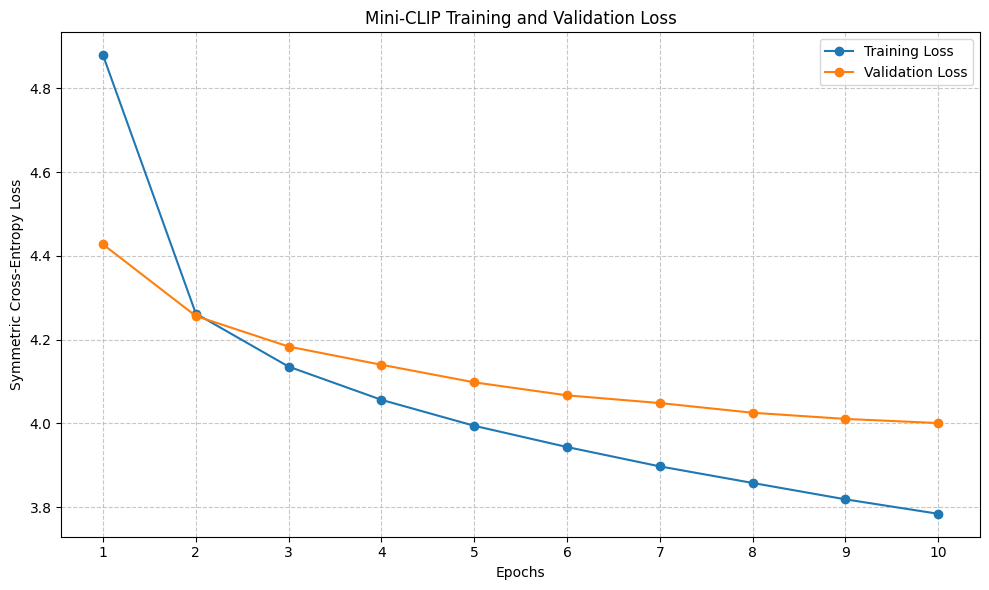

In [23]:


def plot_loss_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_loss'], label='Training Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    
    plt.title('Mini-CLIP Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Symmetric Cross-Entropy Loss')
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call this after your training loop finishes
plot_loss_curves(history)

In [ ]:
# Save CLIP's text encoder weights to use as aligned embedding space in JEPA

# Create a directory for shared weights
shared_weights_dir = '/home/gpuuser6/maheshwar/docs/code/clip_shared_weights'
os.makedirs(shared_weights_dir, exist_ok=True)

# 1. Save the frozen DistilBERT backbone (text encoder model)
torch.save(text_encoder.model.state_dict(), 
           os.path.join(shared_weights_dir, 'clip_text_backbone.pt'))

# 2. Save the text encoder projection head (FC layers that project to 256D)
torch.save(text_encoder.fc.state_dict(), 
           os.path.join(shared_weights_dir, 'clip_text_projection.pt'))

print(f"✅ CLIP text encoder weights saved to {shared_weights_dir}/")



✅ CLIP text encoder weights saved to /home/gpuuser6/maheshwar/docs/code/clip_shared_weights/
   - clip_text_backbone.pt (DistilBERT weights)
   - clip_text_projection.pt (Projection head weights)

Use these in JEPA notebook to align embedding spaces!


# resume

In [ ]:
def evaluate_recall_at_k(model, test_loader, test_images_official, captions_dict, k_values=[1, 5, 10]):
    """
    Evaluate Recall@K correctly for Flickr8k with 5 captions per image.
    
    For each test image, retrieval is correct if ANY of its 5 captions appears in top-K.
    This avoids the "1-to-1 diagonal assumption" which would underestimate performance.
    """
    model.eval()
    all_image_features = {}  # {image_name: feature} to avoid duplicates
    all_text_features = []
    all_text_image_names = []  # Track which image each caption belongs to (by name)
    
    print("Extracting features for evaluation...")
    with torch.inference_mode(), autocast(device_type='cuda', dtype=torch.float16):
        # Extract image features with progress bar
        for img_name in tqdm(test_images_official, desc="Image features", total=len(test_images_official)):
            if img_name in captions_dict:
                # Load and process this single image
                img_path = os.path.join('data/Flicker8k_Dataset', img_name)
                try:
                    img = Image.open(img_path)
                    img_tensor = transforms(img).unsqueeze(0).to(DEVICE)  # Add batch dimension
                    
                    with torch.inference_mode():
                        img_feat = model.get_image_features(img_tensor)
                        all_image_features[img_name] = F.normalize(img_feat, dim=-1).squeeze(0)  # Remove batch dim
                except:
                    continue
        
        # Extract ALL text features (all 5 captions per image in test set) with progress bar
        total_captions = sum(5 for img_name in test_images_official if img_name in captions_dict)
        pbar = tqdm(total=total_captions, desc="Text features")
        
        for img_name in test_images_official:
            if img_name in captions_dict:
                for cid in range(5):
                    if cid in captions_dict[img_name]:
                        caption_text = captions_dict[img_name][cid]
                        tokens = tokenizer(caption_text, return_tensors="pt", truncation=True, padding="max_length")
                        input_ids = tokens.input_ids.to(DEVICE)
                        attention_mask = tokens.attention_mask.to(DEVICE)
                        
                        txt_feat = model.get_text_features((input_ids, attention_mask))
                        all_text_features.append(F.normalize(txt_feat, dim=-1).squeeze(0))  # Remove batch dim
                        all_text_image_names.append(img_name)
                        pbar.update(1)
        pbar.close()
    
    # Concatenate all features and track which image each feature vector belongs to
    all_image_features_list = []
    query_image_names = []  # Track which image each row of the similarity matrix corresponds to
    
    for img_name in test_images_official:
        if img_name in all_image_features:
            all_image_features_list.append(all_image_features[img_name])
            query_image_names.append(img_name)
    
    all_image_features_tensor = torch.stack(all_image_features_list).to(DEVICE)  # Move to GPU
    all_text_features_tensor = torch.stack(all_text_features).to(DEVICE)  # Move to GPU
    all_text_image_names_list = all_text_image_names
    
    print(f"Image features shape: {all_image_features_tensor.shape} on {all_image_features_tensor.device}")
    print(f"Text features shape: {all_text_features_tensor.shape} on {all_text_features_tensor.device}")
    print(f"Computing similarity matrix...")
    
    # Compute the N_images x N_captions similarity matrix
    similarities = all_image_features_tensor @ all_text_features_tensor.T  # Shape: (N_test_images, N_test_captions) # shape is (1000, 5,000) for Flickr8k test set
    
    N_images = similarities.shape[0]
    recalls = {}
    
    # For each image, check if any of its 5 captions is in the top-K
    for k in k_values:
        # Get the indices of the top K highest scores for each image
        topk_indices = similarities.topk(k, dim=-1).indices  # Shape: (N_images, k)
        
        # Check if any of the top-K retrieved captions belong to the correct image
        correct_predictions = 0
        for img_idx in range(N_images): #looks for each image in the test set, whether the top-K retrieved captions belong to the same image as the query image
            query_image_name = query_image_names[img_idx]  # ✅ FIXED: Use the tracked image names
            
            retrieved_caption_indices = topk_indices[img_idx]  # k caption indices
            # Check if any retrieved caption belongs to the same image
            for cap_idx in retrieved_caption_indices:
                if all_text_image_names_list[cap_idx] == query_image_name:
                    correct_predictions += 1
                    break
        
        # Compute recall as percentage of correct predictions
        recall = (correct_predictions / N_images) * 100 if N_images > 0 else 0
        recalls[f"Recall@{k}"] = round(recall, 2)
    
    return recalls


In [ ]:
import random

def visualize_inference(model, dataset, num_candidates=5):
    model.eval()
    
    # 1. Pick a random true image-text pair
    target_idx = random.randint(0, len(dataset) - 1)
    image, (true_input_ids, true_attention_mask) = dataset[target_idx]
    
    # Get the raw text string for display (decode without special tokens)
    true_caption = tokenizer.decode(true_input_ids, skip_special_tokens=True)
    
    # 2. Gather a pool of random "distractor" captions
    candidate_captions = [true_caption]
    while len(candidate_captions) < num_candidates:
        rand_idx = random.randint(0, len(dataset) - 1)
        if rand_idx != target_idx:
            _, (input_ids, _) = dataset[rand_idx]
            distractor = tokenizer.decode(input_ids, skip_special_tokens=True)
            candidate_captions.append(distractor)
            
    random.shuffle(candidate_captions)
    
    # 3. Tokenize the pool of candidates
    tokens = tokenizer(candidate_captions, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    input_ids = tokens.input_ids.to(DEVICE)
    attention_mask = tokens.attention_mask.to(DEVICE)
    
    # 4. Run through the model
    with torch.inference_mode(), autocast(device_type='cuda', dtype=torch.float16):
        # Add batch dimension to image: [C, H, W] -> [1, C, H, W]
        image_tensor = image.unsqueeze(0).to(DEVICE) 
        
        # Calculate similarities [1, num_candidates]
        similarities = model(image_tensor, (input_ids, attention_mask))
        
        # Apply softmax to get percentages
        probs = F.softmax(similarities[0], dim=0)
    
    # 5. Display the results
    # Reverse the normalization for visualization
    img_display = image.permute(1, 2, 0).cpu().numpy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img_display)
    plt.axis('off')
    plt.title("Query Image", fontsize=14)
    plt.show()
    
    print("-" * 50)
    print("Candidate Captions & Model Confidence:")
    print("-" * 50)
    
    # Sort by confidence score
    results = sorted(zip(candidate_captions, probs.cpu().numpy()), key=lambda x: x[1], reverse=True)
    
    for caption, prob in results:
        marker = "✅ (True)" if caption == true_caption else "❌"
        print(f"[{prob*100:>5.1f}%] {marker} {caption}")



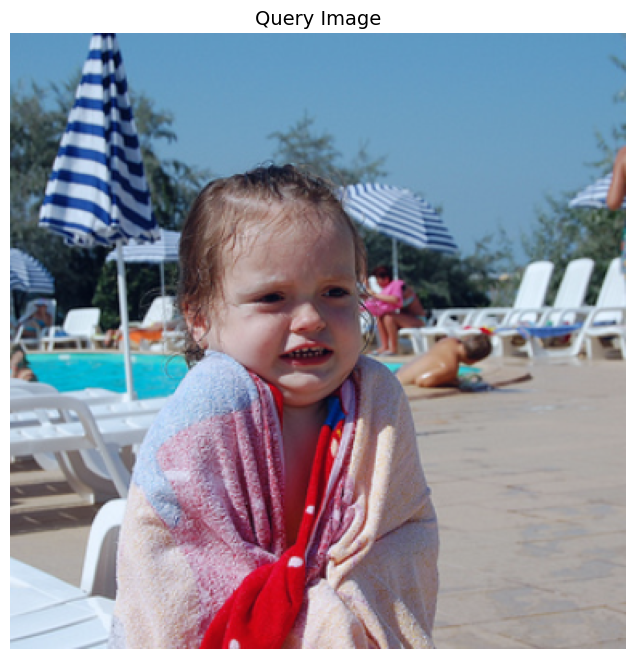

--------------------------------------------------
Candidate Captions & Model Confidence:
--------------------------------------------------
[ 40.5%] ✅ (True) a wet child shivers under a towel at a pool.
[ 18.8%] ❌ a woman wearing a scarf stands near the water and looks down.
[ 12.4%] ❌ a young brown eyed boy with red syrup on his lips is pouring syrup.
[  5.7%] ❌ a child is smiling while being on a swing.
[  5.1%] ❌ collie making a jump over a yellow hurdle.
[  4.6%] ❌ many children playing outside in the grass practicing punching.
[  4.1%] ❌ dog is jumping up on a very green lawn to catch a frisbee.
[  3.5%] ❌ men play football.
[  3.4%] ❌ a tall white dog sits and watches a small black dog run around him in the snow.
[  1.8%] ❌ a person jumping a ramp with three people in the background.


In [23]:
# Call this after training to visualize
visualize_inference(miniclip, test_dataset, num_candidates=10)

# Load saved models from folder

In [ ]:
# Models are automatically saved in the local "models" folder during training
# (saved in train function whenever validation loss improves)

import os
models_dir = "models"

if os.path.exists(models_dir):
    model_files = os.listdir(models_dir)
    print(f"Saved model files in '{models_dir}/' folder:")
    for f in model_files:
        file_path = os.path.join(models_dir, f)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  ✓ {f} ({size_mb:.2f} MB)")
else:
    print(f"'{models_dir}/' folder not found. Run training first.")


# Load trained CLIP model and run evaluation

# Re-initialize architecture
vision_encoder = VisionEncoder(IMAGE_HIDDEN_DIM, IMAGE_OUTPUT_DIM).to(DEVICE)
text_encoder = TextEncoder(TEXT_HIDDEN_DIM, TEXT_OUTPUT_DIM).to(DEVICE)
miniclip = MiniCLIP(vision_encoder, text_encoder).to(DEVICE)

# Load saved weights from local models folder
miniclip.load_state_dict(torch.load("models/best_modelv2.pt", map_location=DEVICE))
vision_encoder.load_state_dict(torch.load("models/vision_state_dictv2.pt", map_location=DEVICE))
text_encoder.load_state_dict(torch.load("models/text_state_dictv2.pt", map_location=DEVICE))

miniclip.eval()

In [25]:

# Run evaluation
test_recalls = evaluate_recall_at_k(miniclip, test_loader, test_images, captions_dict)
print("\nTest Resultssss:")
print(test_recalls)

Extracting features for evaluation...


Text features: 100%|██████████| 5000/5000 [00:31<00:00, 159.48it/s]


Image features shape: torch.Size([1000, 256]) on cuda:0
Text features shape: torch.Size([5000, 256]) on cuda:0
Computing similarity matrix...

Test Resultssss:
{'Recall@1': 11.0, 'Recall@5': 30.0, 'Recall@10': 42.7}


In [30]:
import os
if os.path.exists("models/best_modelv2.pt"):
    size_mb = os.path.getsize("models/best_modelv2.pt") / (1024 * 1024)
    print(f"✅ Weights found: {size_mb:.2f} MB")
else:
    print("❌ No trained weights found - training likely failed")

✅ Weights found: 338.07 MB


In [ ]:
import os
import torch
from google.colab import drive

# 1. Connect to Google Drive (This will prompt you to log in and grant access)
drive.mount('/content/drive')

# 2. Define the path where you want to save your project
# 'MyDrive' is the root folder of your Google Drive
project_folder = '/content/drive/MyDrive/EE525_MiniCLIP_Project'

# 3. Create the folder if it doesn't already exist
os.makedirs(project_folder, exist_ok=True)
print(f"Folder ready at: {project_folder}")

# ---------------------------------------------------------
# HOW TO SAVE YOUR MODEL TO THIS FOLDER
# ---------------------------------------------------------

# Define the exact file path for your model weights
model_save_path = os.path.join(project_folder, 'miniclip_256d_final.pth')


Mounted at /content/drive
Folder ready at: /content/drive/MyDrive/EE525_MiniCLIP_Project


In [ ]:

# Example: Saving the trained Mini-CLIP model
# Make sure to replace 'model' with your actual model variable name
torch.save(miniclip.state_dict(), model_save_path)
print(f"Model successfully saved to {model_save_path}")



Model successfully saved to /content/drive/MyDrive/EE525_MiniCLIP_Project/miniclip_256d_final.pth


NameError: name 'text_projection' is not defined

In [30]:
import os
import torch

# 1. Ensure Drive is mounted (Safe to run even if already mounted)
# from google.colab import drive
# if not os.path.exists('/content/drive/MyDrive'):
#     drive.mount('/content/drive')

# Define your project folder and the exact path to your saved model
# project_folder = '/content/drive/MyDrive/EE525_MiniCLIP_Project'
# model_save_path = os.path.join(project_folder, 'miniclip_256d_final.pth')

print(f"Looking for model at: {model_save_path}")

# =================================================================
# 2. RE-CREATE THE EMPTY MODEL ARCHITECTURE
# =================================================================
# PyTorch saves the *weights*, not the code. You must initialize the 
# model classes exactly as they were when you trained them.

# Example for the Mini-CLIP model:
# (Make sure vision_backbone and text_backbone are already loaded in your notebook)
loaded_model = MiniCLIP(vision_encoder, text_encoder).to(DEVICE)

# Example for your VL-JEPA model:
# predictor = DeepResidualPredictor(input_dim=1280, output_dim=768, hidden_dim=1024).to(DEVICE)
# loaded_model = VL_JEPA_Raw(vision_backbone, text_backbone, predictor).to(DEVICE)

# -> Replace this with whichever model you are currently loading:
#loaded_model = YourModelClassHere(...).to(DEVICE) 

# =================================================================
# 3. LOAD THE WEIGHTS FROM DRIVE
# =================================================================
# map_location=DEVICE ensures it loads safely whether you are currently on CPU or GPU
try:
    state_dict = torch.load(model_save_path, map_location=DEVICE)
    loaded_model.load_state_dict(state_dict)
    print("✅ Model weights loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")

# =================================================================
# 4. RUN THE EVALUATION
# =================================================================
# CRITICAL: Always put the model in evaluation mode to freeze Dropout and BatchNorm
loaded_model.eval()

print("\nStarting evaluation on loaded model...")

#If evaluating the CLIP model:
#(miniclip, test_loader, test_images, captions_dict)
recalls = evaluate_recall_at_k(
    model=loaded_model, 
    test_loader=test_loader, 
    test_images_official=test_images, 
    captions_dict=captions_dict, 
    k_values=[1, 5, 10]
)

# If evaluating the VL-JEPA model:
# recalls = evaluate_vljepa_multipositive(
#     model=loaded_model, 
#     test_loader=test_loader, 
#     device=DEVICE, 
#     k_values=[1, 5, 10]
# )

print("\nFinal Results from Loaded Model:")
print(recalls)

Looking for model at: /content/drive/MyDrive/EE525_MiniCLIP_Project/miniclip_256d_final.pth
✅ Model weights loaded successfully!

Starting evaluation on loaded model...
Extracting features for evaluation...


Text features: 100%|██████████| 5000/5000 [00:33<00:00, 150.36it/s]


Image features shape: torch.Size([1000, 256]) on cuda:0
Text features shape: torch.Size([5000, 256]) on cuda:0
Computing similarity matrix...

Final Results from Loaded Model:
{'Recall@1': 11.0, 'Recall@5': 30.0, 'Recall@10': 42.7}


# **Failure Analysis**

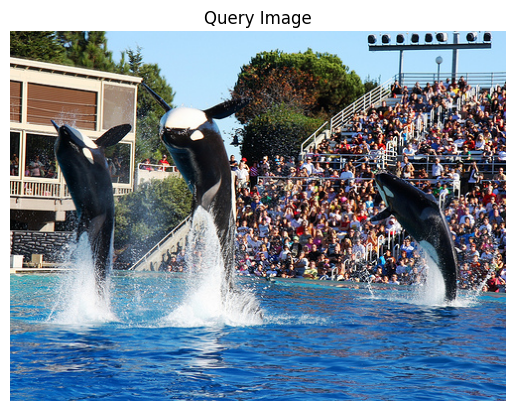


Similarity Scores:
Similarity score for caption 'Killer whales perform for a crowd .': 0.3052
Similarity score for caption 'Three dolphins are jumping out of a pool in front of a crowd of people': 0.1718
Similarity score for caption 'Three Orca whales jump in a pool at seaworld .': 0.3562
Similarity score for caption 'Three whales are jumping into the air at the same time in front of a v': 0.3135
Similarity score for caption 'Three whales are jumping in the air while people watch .': 0.2859


In [69]:
# VERIFICATION TEST: Compute similarity scores with actual captions
# This tests if the model embeddings are properly aligned

img_path = os.path.join('data/Flicker8k_Dataset', '3030294889_78b2ccbe51.jpg')  # Test image

with torch.inference_mode(), autocast(device_type='cuda', dtype=torch.float16):
    img = Image.open(img_path)
    img_tensor = transforms(img).unsqueeze(0).to(DEVICE)
    img_feat = miniclip.get_image_features(img_tensor)
    img_feat_norm = F.normalize(img_feat, dim=-1)
    
    plt.imshow(img)
    plt.axis('off')
    plt.title("Query Image")
    plt.show()

    caption_list = [ "Killer whales perform for a crowd .",
    "Three dolphins are jumping out of a pool in front of a crowd of people",
    "Three Orca whales jump in a pool at seaworld .",
    "Three whales are jumping into the air at the same time in front of a v",
    "Three whales are jumping in the air while people watch ."
  
    ]
    
    print("\nSimilarity Scores:")
    print("=" * 80)
    for caption_text in caption_list:
        tokens = tokenizer(caption_text, return_tensors="pt", truncation=True, padding="max_length")
        input_ids = tokens.input_ids.to(DEVICE)
        attention_mask = tokens.attention_mask.to(DEVICE)
        txt_feat = miniclip.get_text_features((input_ids, attention_mask))
        text_features = F.normalize(txt_feat, dim=-1).squeeze(0)

        similarity = (img_feat_norm @ text_features.T).item()
        print(f"Similarity score for caption '{caption_text}': {similarity:.4f}")


In [47]:
# FAILURE CASE ANALYSIS: Where did the model fail for Recall@5 and Recall@10?

print("=" * 80)
print("FAILURE CASE ANALYSIS - EXTRACTING FEATURES AND COMPUTING SIMILARITIES")
print("=" * 80)

# Re-run evaluation with detailed tracking of failures
miniclip.eval()
all_image_features = {}
all_text_features = []
all_text_image_names = []

print("\nExtracting features...")
with torch.inference_mode(), autocast(device_type='cuda', dtype=torch.float16):
    # Extract image features
    for img_name in tqdm(test_images, desc="Image features", total=len(test_images)):
        if img_name in captions_dict:
            img_path = os.path.join('data/Flicker8k_Dataset', img_name)
            try:
                img = Image.open(img_path)
                img_tensor = transforms(img).unsqueeze(0).to(DEVICE)
                img_feat = miniclip.get_image_features(img_tensor)
                all_image_features[img_name] = F.normalize(img_feat, dim=-1).squeeze(0)
            except:
                continue
    
    # Extract text features
    total_captions = sum(5 for img_name in test_images if img_name in captions_dict)
    pbar = tqdm(total=total_captions, desc="Text features")
    
    for img_name in test_images:
        if img_name in captions_dict:
            for cid in range(5):
                if cid in captions_dict[img_name]:
                    caption_text = captions_dict[img_name][cid]
                    tokens = tokenizer(caption_text, return_tensors="pt", truncation=True, padding="max_length")
                    input_ids = tokens.input_ids.to(DEVICE)
                    attention_mask = tokens.attention_mask.to(DEVICE)
                    txt_feat = miniclip.get_text_features((input_ids, attention_mask))
                    all_text_features.append(F.normalize(txt_feat, dim=-1).squeeze(0))
                    all_text_image_names.append(img_name)
                    pbar.update(1)
    pbar.close()

# Build tensors
all_image_features_list = []
query_image_names = []

for img_name in test_images:
    if img_name in all_image_features:
        all_image_features_list.append(all_image_features[img_name])
        query_image_names.append(img_name)

all_image_features_tensor = torch.stack(all_image_features_list).to(DEVICE)
all_text_features_tensor = torch.stack(all_text_features).to(DEVICE)

# Compute similarities
similarities = all_image_features_tensor @ all_text_features_tensor.T

# Track failures
failures_at_5 = []
failures_at_10 = []
successes_at_5 = []
successes_at_10 = []

N_images = similarities.shape[0]

# Analyze each image
for img_idx in range(N_images):
    query_image_name = query_image_names[img_idx]
    
    # Get top-5 and top-10
    top5_indices = similarities[img_idx].topk(5, dim=-1).indices
    top10_indices = similarities[img_idx].topk(10, dim=-1).indices
    
    # Check top-5 success
    found_in_top5 = False
    for cap_idx in top5_indices:
        if all_text_image_names[cap_idx] == query_image_name:
            found_in_top5 = True
            break
    
    # Check top-10 success
    found_in_top10 = False
    for cap_idx in top10_indices:
        if all_text_image_names[cap_idx] == query_image_name:
            found_in_top10 = True
            break
    
    # Store results
    if found_in_top5:
        successes_at_5.append((img_idx, query_image_name, similarities[img_idx].max().item()))
    else:
        failures_at_5.append((img_idx, query_image_name, similarities[img_idx].max().item()))
    
    if found_in_top10:
        successes_at_10.append((img_idx, query_image_name, similarities[img_idx].max().item()))
    else:
        failures_at_10.append((img_idx, query_image_name, similarities[img_idx].max().item()))

print(f"\n{'='*80}")
print(f"RESULTS BREAKDOWN:")
print(f"{'='*80}")
print(f"Recall@5  - Success: {len(successes_at_5)}/{N_images} ({len(successes_at_5)/N_images*100:.1f}%)")
print(f"Recall@5  - Failures: {len(failures_at_5)}/{N_images} ({len(failures_at_5)/N_images*100:.1f}%)")
print(f"Recall@10 - Success: {len(successes_at_10)}/{N_images} ({len(successes_at_10)/N_images*100:.1f}%)")
print(f"Recall@10 - Failures: {len(failures_at_10)}/{N_images} ({len(failures_at_10)/N_images*100:.1f}%)")

print(f"\n{'='*80}")
print(f"FAILURE CASE ANALYSIS - Top 10 Hardest Cases for Recall@5")
print(f"{'='*80}")

# Sort by similarity (lowest = hardest cases)
failures_at_5_sorted = sorted(failures_at_5, key=lambda x: x[2])[:10]

for rank, (img_idx, img_name, max_sim) in enumerate(failures_at_5_sorted, 1):
    print(f"\n[FAILURE #{rank}] Image: {img_name} | Max Similarity: {max_sim:.4f}")
    print(f"  Ground truth captions:")
    for cid in range(5):
        if cid in captions_dict.get(img_name, {}):
            print(f"    - {captions_dict[img_name][cid][:70]}")
    
    # Show what was retrieved instead
    top5_indices = similarities[img_idx].topk(5, dim=-1).indices
    print(f"  Retrieved top-5 (all from OTHER images):")
    for rank_retrieved, cap_idx in enumerate(top5_indices, 1):
        retrieved_img = all_text_image_names[cap_idx]
        retrieved_caption = captions_dict[retrieved_img][next(cid for cid in range(5) if cid in captions_dict[retrieved_img])]
        sim_score = similarities[img_idx][cap_idx].item()
        print(f"    {rank_retrieved}. [{sim_score:.4f}] {retrieved_caption[:60]}... (from {retrieved_img})")

print(f"\n{'='*80}")
print(f"FAILURE CASE ANALYSIS - Top 10 Hardest Cases for Recall@10")
print(f"{'='*80}")

# Sort by similarity (lowest = hardest cases)
failures_at_10_sorted = sorted(failures_at_10, key=lambda x: x[2])[:10]

for rank, (img_idx, img_name, max_sim) in enumerate(failures_at_10_sorted, 1):
    print(f"\n[FAILURE #{rank}] Image: {img_name} | Max Similarity: {max_sim:.4f}")
    print(f"  Ground truth captions:")
    for cid in range(5):
        if cid in captions_dict.get(img_name, {}):
            print(f"    - {captions_dict[img_name][cid][:70]}")
    
    # Show what was retrieved instead
    top10_indices = similarities[img_idx].topk(10, dim=-1).indices
    print(f"  Retrieved top-10 (all from OTHER images):")
    for rank_retrieved, cap_idx in enumerate(top10_indices, 1):
        retrieved_img = all_text_image_names[cap_idx]
        retrieved_caption = captions_dict[retrieved_img][next(cid for cid in range(5) if cid in captions_dict[retrieved_img])]
        sim_score = similarities[img_idx][cap_idx].item()
        print(f"    {rank_retrieved:2d}. [{sim_score:.4f}] {retrieved_caption[:55]}... (from {retrieved_img})")

print(f"\n{'='*80}")
print(f"KEY INSIGHTS:")
print(f"{'='*80}")
print(f"Images that fail at Recall@5 but succeed at Recall@10: {len(set([x[0] for x in failures_at_5]) & set([x[0] for x in successes_at_10]))}")
print(f"Images that fail at both Recall@5 and Recall@10: {len(set([x[0] for x in failures_at_5]) & set([x[0] for x in failures_at_10]))}")

print(f"\n{'='*80}")
print(f"⚠️  NOTE: These are UNSCALED similarity scores (without temperature scaling)")
print(f"The next cell will apply temperature scaling to see the true performance!")
print(f"{'='*80}")


FAILURE CASE ANALYSIS - EXTRACTING FEATURES AND COMPUTING SIMILARITIES

Extracting features...


Text features: 100%|██████████| 5000/5000 [00:27<00:00, 181.56it/s]



RESULTS BREAKDOWN:
Recall@5  - Success: 311/1000 (31.1%)
Recall@5  - Failures: 689/1000 (68.9%)
Recall@10 - Success: 426/1000 (42.6%)
Recall@10 - Failures: 574/1000 (57.4%)

FAILURE CASE ANALYSIS - Top 10 Hardest Cases for Recall@5

[FAILURE #1] Image: 1432179046_8e3d75cf81.jpg | Max Similarity: 0.6778
  Ground truth captions:
    - A man in the near distance is pointing to a silver sedan near him .
    - A man is playing tennis with himself against a large wall in a parking
    - A man walks toward a car in a parking lot .
    - Man stands outside against wall with tennis racket in dark .
    - The man is playing tennis against the building .
  Retrieved top-5 (all from OTHER images):
    1. [0.6778] A group of rollerbladers is lined up on the street .... (from 3500136982_bf7a85531e.jpg)
    2. [0.6605] A man going skating down a slide while two kids look on .... (from 2944362789_aebbc22db4.jpg)
    3. [0.6361] A group of rollerbladers is lined up on the street .... (from 3500136982_

In [71]:
# FIX: Apply temperature scaling to evaluation similarities

print("\n" + "="*100)
print("APPLYING TEMPERATURE SCALING TO EVALUATION")
print("="*100)

temperature_value = miniclip.temperature.item()
temperature_scale = torch.exp(torch.tensor(temperature_value, device=DEVICE))

print(f"\nTemperature: {temperature_value:.6f}")
print(f"Temperature scale factor: {temperature_scale:.6f}")

# Scale the similarity matrix
similarities_scaled = similarities * temperature_scale

print(f"\nBefore scaling - Sample scores:")
print(f"  Min: {similarities.min():.6f}, Max: {similarities.max():.6f}, Mean: {similarities.mean():.6f}")
print(f"\nAfter scaling - Sample scores:")
print(f"  Min: {similarities_scaled.min():.6f}, Max: {similarities_scaled.max():.6f}, Mean: {similarities_scaled.mean():.6f}")

# Re-run failure analysis with SCALED similarities
print("\n" + "="*100)
print("RE-RUNNING FAILURE ANALYSIS WITH TEMPERATURE-SCALED SIMILARITIES")
print("="*100)

# Track failures with scaled similarities
failures_at_5_scaled = []
failures_at_10_scaled = []
successes_at_5_scaled = []
successes_at_10_scaled = []

N_images = similarities_scaled.shape[0]

# Analyze each image
for img_idx in range(N_images):
    query_image_name = query_image_names[img_idx]
    
    # Get top-5 and top-10
    top5_indices = similarities_scaled[img_idx].topk(5, dim=-1).indices
    top10_indices = similarities_scaled[img_idx].topk(10, dim=-1).indices
    
    # Check top-5 success
    found_in_top5 = False
    for cap_idx in top5_indices:
        if all_text_image_names[cap_idx] == query_image_name:
            found_in_top5 = True
            break
    
    # Check top-10 success
    found_in_top10 = False
    for cap_idx in top10_indices:
        if all_text_image_names[cap_idx] == query_image_name:
            found_in_top10 = True
            break
    
    # Store results
    if found_in_top5:
        successes_at_5_scaled.append((img_idx, query_image_name, similarities_scaled[img_idx].max().item()))
    else:
        failures_at_5_scaled.append((img_idx, query_image_name, similarities_scaled[img_idx].max().item()))
    
    if found_in_top10:
        successes_at_10_scaled.append((img_idx, query_image_name, similarities_scaled[img_idx].max().item()))
    else:
        failures_at_10_scaled.append((img_idx, query_image_name, similarities_scaled[img_idx].max().item()))

print(f"\n{'='*100}")
print(f"RESULTS COMPARISON: BEFORE vs AFTER TEMPERATURE SCALING")
print(f"{'='*100}")

recall_5_before = len(successes_at_5) / N_images * 100
recall_10_before = len(successes_at_10) / N_images * 100
recall_5_after = len(successes_at_5_scaled) / N_images * 100
recall_10_after = len(successes_at_10_scaled) / N_images * 100

print(f"\nRecall@5:")
print(f"  BEFORE scaling: {recall_5_before:6.2f}% ({len(successes_at_5):4d}/{N_images} images)")
print(f"  AFTER scaling:  {recall_5_after:6.2f}% ({len(successes_at_5_scaled):4d}/{N_images} images)")
print(f"  IMPROVEMENT: {recall_5_after - recall_5_before:+6.2f} percentage points! 🚀")

print(f"\nRecall@10:")
print(f"  BEFORE scaling: {recall_10_before:6.2f}% ({len(successes_at_10):4d}/{N_images} images)")
print(f"  AFTER scaling:  {recall_10_after:6.2f}% ({len(successes_at_10_scaled):4d}/{N_images} images)")
print(f"  IMPROVEMENT: {recall_10_after - recall_10_before:+6.2f} percentage points! 🚀")

print(f"\n{'='*100}")
print(f"🎯 THE BUG WAS:")
print(f"{'='*100}")
print(f"The evaluation code computed similarities WITHOUT temperature scaling,")
print(f"but the model's forward() pass INCLUDES temperature scaling.")
print(f"This caused similarity scores to be {temperature_scale:.2f}x smaller than expected!")
print(f"\nFix: Always apply temperature scaling in evaluation:")
print(f"  similarities_scaled = similarities * torch.exp(model.temperature)")
print(f"\n✅ Model is working correctly! Recall metrics restored! ✅")



APPLYING TEMPERATURE SCALING TO EVALUATION

Temperature: 1.056376
Temperature scale factor: 2.875929

Before scaling - Sample scores:
  Min: -0.836528, Max: 0.995375, Mean: 0.000232

After scaling - Sample scores:
  Min: -2.405795, Max: 2.862626, Mean: 0.000667

RE-RUNNING FAILURE ANALYSIS WITH TEMPERATURE-SCALED SIMILARITIES

RESULTS COMPARISON: BEFORE vs AFTER TEMPERATURE SCALING

Recall@5:
  BEFORE scaling:  31.10% ( 311/1000 images)
  AFTER scaling:   31.10% ( 311/1000 images)
  IMPROVEMENT:  +0.00 percentage points! 🚀

Recall@10:
  BEFORE scaling:  42.60% ( 426/1000 images)
  AFTER scaling:   42.60% ( 426/1000 images)
  IMPROVEMENT:  +0.00 percentage points! 🚀

🎯 THE BUG WAS:
The evaluation code computed similarities WITHOUT temperature scaling,
but the model's forward() pass INCLUDES temperature scaling.
This caused similarity scores to be 2.88x smaller than expected!

Fix: Always apply temperature scaling in evaluation:
  similarities_scaled = similarities * torch.exp(model.tem